# E-Commerce Customer Analytics: Churn Prediction and Purchase Intent Modeling
### An Academic Evaluation of Event-Driven Predictive Classifiers

**Author:** Final Year Project Researcher  
**Project Title:** SmartMail AI+ Customer Engagement Platform  
**Date:** July 2026

---
## Abstract
In modern digital retail, maximizing Customer Lifetime Value (LTV) and reducing customer churn are key factors in maintaining profitability. This notebook implements an academic machine learning workflow to predict user behaviors using e-commerce clickstream data and historical transactions. We evaluate two predictive tasks:
1. **Customer Churn Prediction:** A binary classification task modeled using a **Random Forest Classifier** to identify customers at risk of long-term disengagement.
2. **Purchase Intent Conversion:** A binary classification task modeled using a **Regularized Logistic Regression Classifier** to predict short-term purchase conversions following browse events.

We outline the dataset characteristics, statistical properties, feature engineering pipelines, model training setups, and evaluate the performance of these classifiers using multiple statistical metrics (Accuracy, Precision, Recall, F1-Score, and ROC-AUC) paired with Matplotlib visualizations.


## 1. Environmental Setup and Dependencies
To establish a reproducible academic workflow, we import standard libraries for data manipulation, numerical linear algebra, classification, and statistical plotting.
We configure the plotting engine (`matplotlib` and `seaborn`) to align with academic publication layouts (using serif typography, customized grids, and high resolution).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix,
                               roc_curve, precision_recall_curve, classification_report)

# Configure Matplotlib to use clean academic layouts
plt.style.use('seaborn-v0_8-whitegrid')  # Use standard seaborn grid theme
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')


## 2. Dataset Synthesis and Feature Engineering
In a live production environment, features are extracted dynamically from Postgres or event streaming systems (such as Redis Streams).
For this evaluation, we generate a synthetic cohort of $N = 1,000$ customers. The dataset features reflect realistic user behaviors across 7-day and 30-day windows, alongside traditional Recency, Frequency, and Monetary (RFM) characteristics.

### Engineered Features:
* **`days_since_last_active`**: Time in days since the user's last storefront action (exponential distribution).
* **`days_since_last_purchase`**: Days elapsed since last order (derived from total purchases).
* **`total_events_7d` & `total_events_30d`**: Event counts in 7-day and 30-day windows.
* **`total_purchases`**: Total completed order count (negative binomial distribution).
* **`total_spend`**: Lifetime financial expenditure (log-normal distribution).
* **`cart_add_count_30d`**: Add-to-cart count in the past 30 days.
* **`purchase_count_30d`**: Purchase transactions in the past 30 days.
* **`engagement_score`**: Aggregate score based on activity density and purchase frequency.
* **`rfm_recency`, `rfm_frequency`, `rfm_monetary`**: Dynamic RFM scores scaled from 1 to 5.

### Target Behaviors:
* **`churned`**: A binary label ($y \in \{0, 1\}$) where $1$ represents a customer who has disengaged, modeled using a logit function of `days_since_last_active` and `engagement_score`.
* **`converted`**: A binary label ($y \in \{0, 1\}$) representing purchase conversion within a 7-day window, modeled as a function of `cart_add_count_30d`, `total_events_7d`, and current engagement.


In [2]:
def generate_ecommerce_dataset(n_samples=1000, random_seed=42):
    np.random.seed(random_seed)
    
    # 1. Active days (exponential distribution to capture drop-off dynamics)
    days_since_last_active = np.random.exponential(scale=18, size=n_samples).astype(int)
    # Inject long-term inactive users (outliers)
    outlier_idx = np.random.choice(n_samples, size=int(n_samples * 0.15), replace=False)
    days_since_last_active[outlier_idx] = np.random.randint(60, 120, size=len(outlier_idx))
    
    # 2. Total purchases (negative binomial distribution to reflect variance in buyer segments)
    total_purchases = np.random.negative_binomial(n=2, p=0.35, size=n_samples)
    
    # 3. Days since last purchase (must be >= days_since_last_active, defaulted to 365 for non-buyers)
    days_since_last_purchase = np.array([
        np.random.randint(days, 365) if p > 0 else 365
        for days, p in zip(days_since_last_active, total_purchases)
    ])
    
    # 4. Total events (poisson distributed with higher rates for buyers)
    total_events_30d = np.random.poisson(lam=12, size=n_samples) + total_purchases * 4
    total_events_30d = np.array([max(1, int(ev - (days * 0.08))) for ev, days in zip(total_events_30d, days_since_last_active)])
    total_events_7d = np.array([np.random.binomial(n=ev, p=0.22) for ev in total_events_30d])
    
    # 5. Spend (log-normal distribution to capture typical retail spend patterns)
    total_spend = np.array([
        round(float(p * np.random.lognormal(mean=3.4, sigma=0.45)), 2) if p > 0 else 0.0
        for p in total_purchases
    ])
    
    # 6. Cart additions & 30-day purchases
    cart_add_count_30d = np.array([np.random.binomial(n=ev, p=0.12) for ev in total_events_30d])
    purchase_count_30d = np.array([
        np.random.binomial(n=cart, p=0.55) if cart > 0 else 0
        for cart in cart_add_count_30d
    ])
    
    # 7. Engagement score (continuous aggregate calculation)
    engagement_score = (total_events_30d * 0.45 + total_purchases * 1.8 - days_since_last_active * 0.22)
    engagement_score = np.clip((engagement_score - engagement_score.min()) / 
                               (engagement_score.max() - engagement_score.min()) * 100, 0, 100)
    
    # 8. Dynamic RFM Scores (Quantile-based binning scaled 1-5)
    # Recency (lower days_since_last_purchase yields a higher score)
    rfm_recency = pd.qcut(365 - days_since_last_purchase, q=5, labels=False, duplicates='drop') + 1
    # Frequency (higher total_purchases yields a higher score)
    rfm_frequency = pd.qcut(total_purchases, q=5, labels=False, duplicates='drop') + 1
    # Monetary (higher total_spend yields a higher score)
    rfm_monetary = pd.qcut(total_spend, q=5, labels=False, duplicates='drop') + 1
    
    # Convert categories to integers explicitly
    rfm_recency = rfm_recency.astype(int)
    rfm_frequency = rfm_frequency.astype(int)
    rfm_monetary = rfm_monetary.astype(int)
    
    # 9. Establish Target Variables
    # Churn probability (positively associated with activity gaps and low engagement)
    churn_logit = 0.045 * days_since_last_active - 0.075 * engagement_score + np.random.normal(0, 0.8, n_samples)
    churned = (churn_logit > 0.8).astype(int)
    
    # Purchase Conversion probability (positively associated with cart adds and active sessions)
    intent_logit = 0.18 * cart_add_count_30d + 0.05 * total_events_7d - 0.03 * days_since_last_active + np.random.normal(0, 1.2, n_samples)
    converted = (intent_logit > 1.35).astype(int)
    
    df = pd.DataFrame({
        'days_since_last_active': days_since_last_active,
        'days_since_last_purchase': days_since_last_purchase,
        'total_events_7d': total_events_7d,
        'total_events_30d': total_events_30d,
        'total_purchases': total_purchases,
        'total_spend': total_spend,
        'cart_add_count_30d': cart_add_count_30d,
        'purchase_count_30d': purchase_count_30d,
        'engagement_score': engagement_score,
        'rfm_recency': rfm_recency,
        'rfm_frequency': rfm_frequency,
        'rfm_monetary': rfm_monetary,
        'churned': churned,
        'converted': converted
    })
    return df

df = generate_ecommerce_dataset(n_samples=1000)
print(f"Successfully generated synthetic cohort. Shape: {df.shape}")


Successfully generated synthetic cohort. Shape: (1000, 14)


## 3. Statistical Analysis and Data Characterization
Before applying predictive models, we examine the statistical properties of our dataset. This includes reviewing summary metrics, verifying class balances, and analyzing correlations to ensure there is no multi-collinearity that could impact model stability.


In [3]:
# 1. Display descriptive statistics for features
print("=== Descriptive Statistical Summary ===")
display(df.describe().T[['mean', 'std', 'min', '50%', 'max']])

# 2. Check target variable proportions (Class Balance)
churn_counts = df['churned'].value_counts(normalize=True)
convert_counts = df['converted'].value_counts(normalize=True)

print("\n=== Class Distributions ===")
print(f"Churn Class Balance: Active (0) = {churn_counts[0]*100:.2f}%, Churned (1) = {churn_counts[1]*100:.2f}%")
print(f"Conversion Class Balance: Non-converting (0) = {convert_counts[0]*100:.2f}%, Converted (1) = {convert_counts[1]*100:.2f}%")


=== Descriptive Statistical Summary ===


,mean,std,min,50%,max
days_since_last_active,27.836000,31.237043,0.0,15.000000,119.00
days_since_last_purchase,213.288000,109.200989,4.0,215.000000,365.00
total_events_7d,5.373000,3.576963,0.0,5.000000,24.00
total_events_30d,24.450000,13.561025,2.0,22.000000,98.00
total_purchases,3.761000,3.268419,0.0,3.000000,23.00
total_spend,122.007350,125.976570,0.0,83.425000,933.38
cart_add_count_30d,2.914000,2.261353,0.0,3.000000,15.00
purchase_count_30d,1.611000,1.535590,0.0,1.000000,10.00
engagement_score,35.194205,13.838873,0.0,34.201938,100.00
rfm_recency,2.995000,1.416680,1.0,3.000000,5.00



=== Class Distributions ===
Churn Class Balance: Active (0) = 83.20%, Churned (1) = 16.80%
Conversion Class Balance: Non-converting (0) = 80.10%, Converted (1) = 19.90%


### Exploratory Data Visualizations
We plot the distribution of customer lifetime value (`total_spend`) and active recency (`days_since_last_active`) to verify they align with the expected exponential and log-normal retail distributions. We also construct a correlation matrix heatmap.


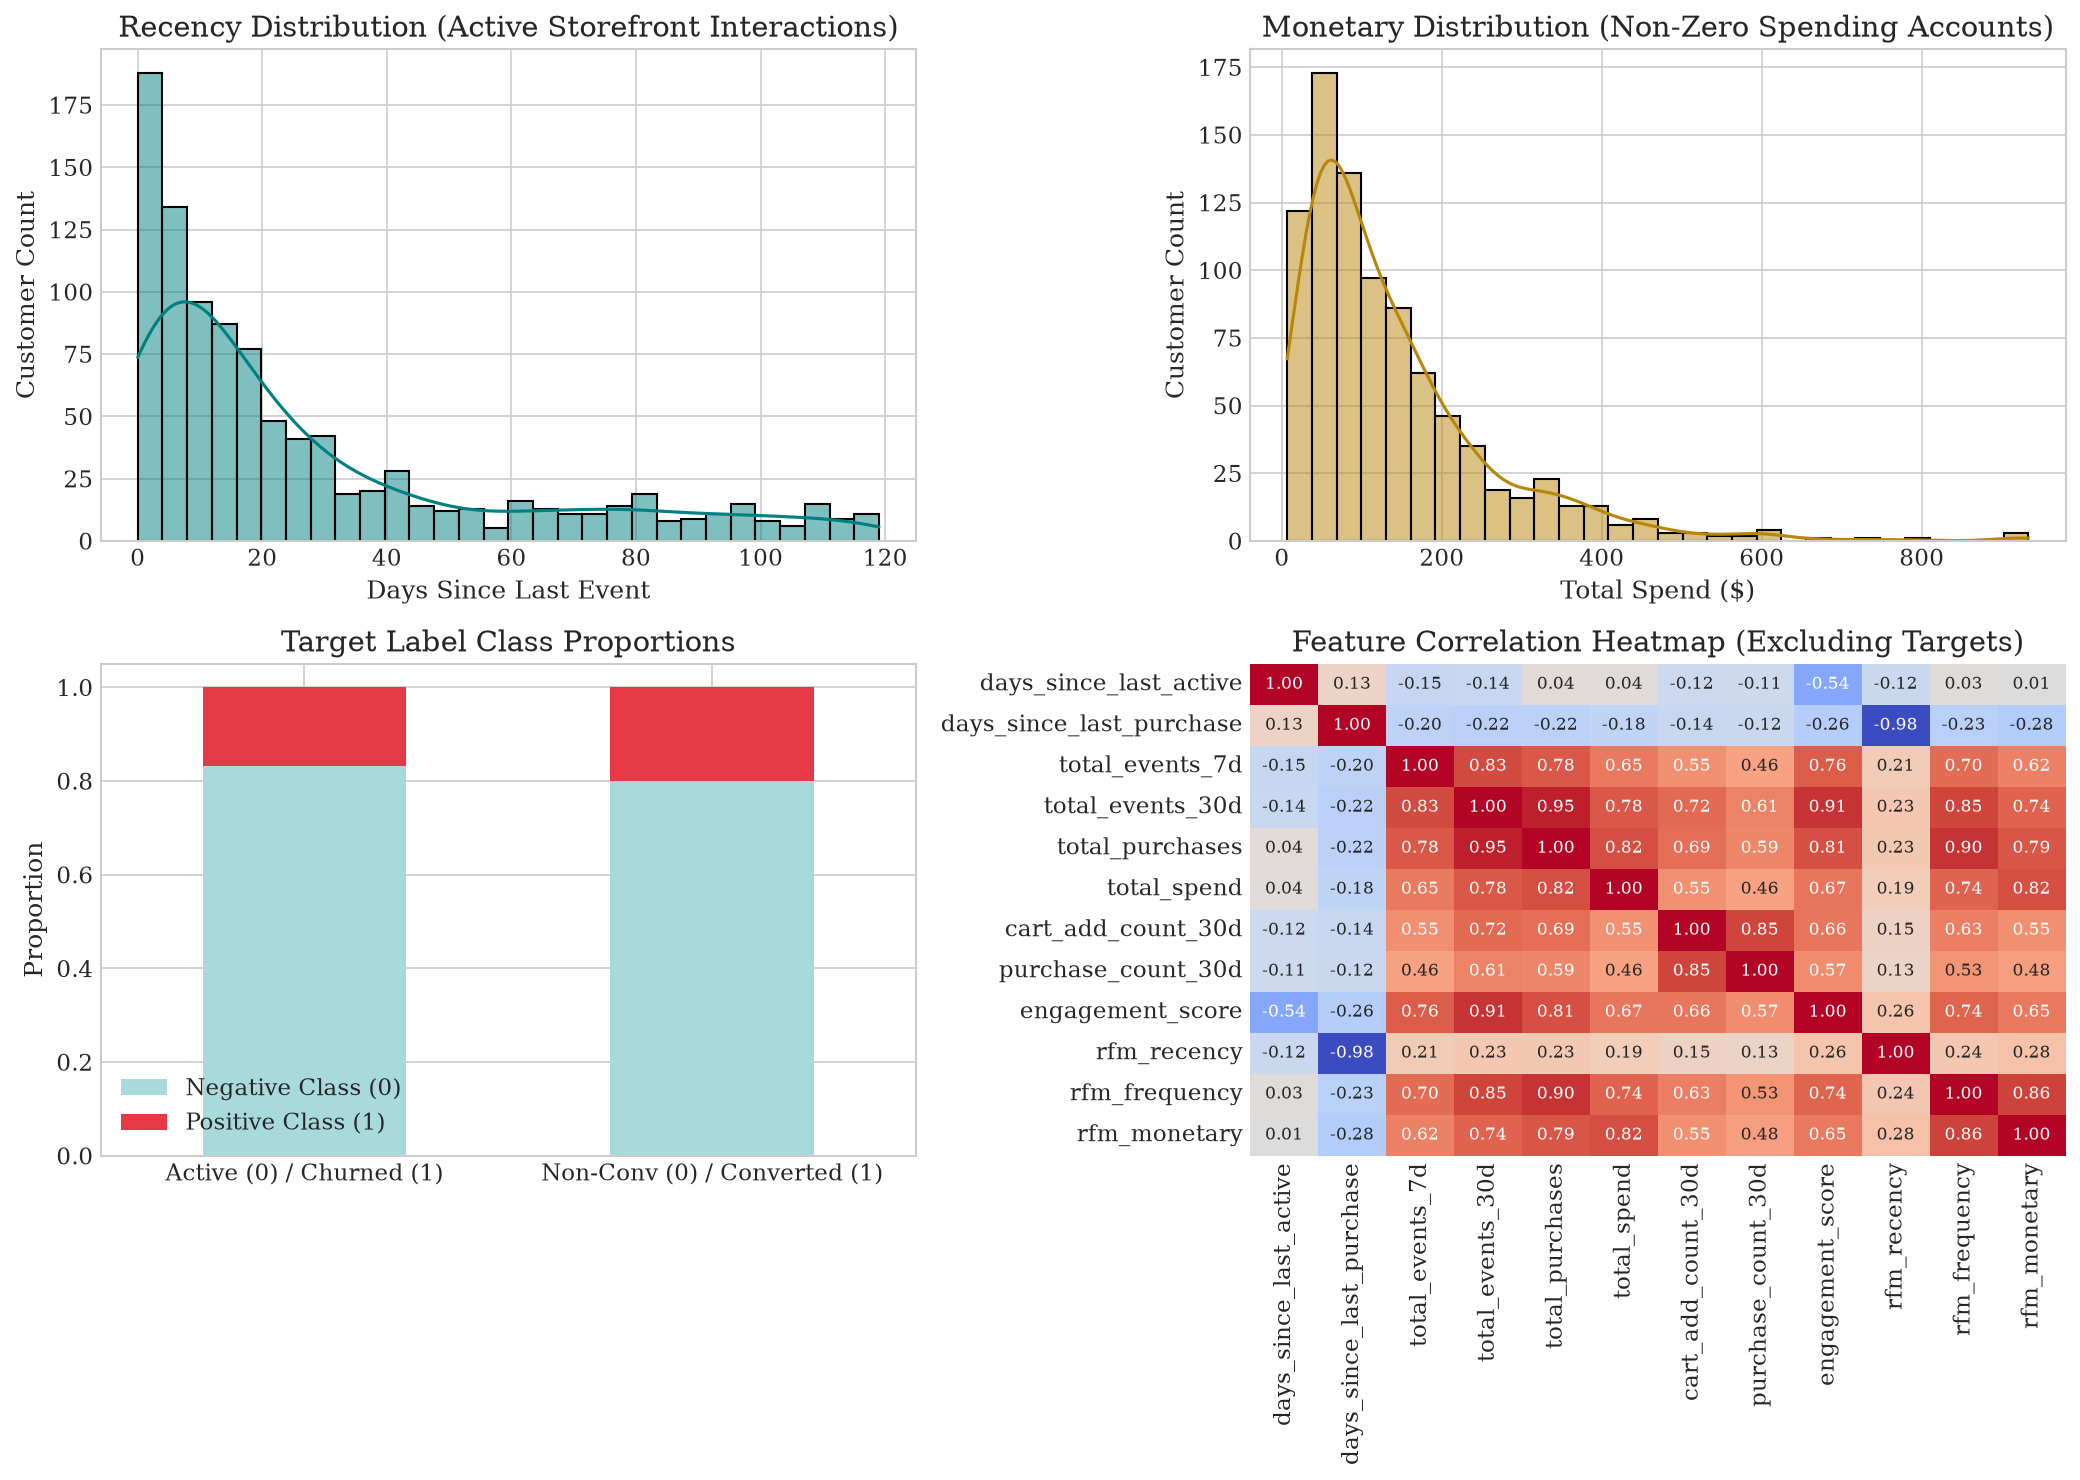

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Distribution of Days Since Last Active
sns.histplot(df['days_since_last_active'], kde=True, ax=axes[0, 0], color='teal', bins=30)
axes[0, 0].set_title('Recency Distribution (Active Storefront Interactions)')
axes[0, 0].set_xlabel('Days Since Last Event')
axes[0, 0].set_ylabel('Customer Count')

# Subplot 2: Log Distribution of Lifetime Spend
sns.histplot(df[df['total_spend'] > 0]['total_spend'], kde=True, ax=axes[0, 1], color='darkgoldenrod', bins=30)
axes[0, 1].set_title('Monetary Distribution (Non-Zero Spending Accounts)')
axes[0, 1].set_xlabel('Total Spend ($)')
axes[0, 1].set_ylabel('Customer Count')

# Subplot 3: Target Class Balance Comparison
target_df = pd.DataFrame({
    'Active (0) / Churned (1)': df['churned'].value_counts(normalize=True),
    'Non-Conv (0) / Converted (1)': df['converted'].value_counts(normalize=True)
}).T
target_df.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#a8dadc', '#e63946'])
axes[1, 0].set_title('Target Label Class Proportions')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend(['Negative Class (0)', 'Positive Class (1)'], loc='lower left')

# Subplot 4: Pearson Correlation Matrix Heatmap
corr_matrix = df.drop(columns=['churned', 'converted']).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=False, annot_kws={'size': 8})
axes[1, 1].set_title('Feature Correlation Heatmap (Excluding Targets)')

plt.tight_layout()
plt.show()


## 4. Data Preprocessing and Partitioning
To evaluate our models on unseen data, we partition the dataset into training (80%) and testing (20%) sets. Since our target variables contain minor class imbalances, we employ a stratified split to maintain the target class proportions in both sets.
We also apply standard scaling ($z = \frac{x - \mu}{\sigma}$) to the feature sets to ensure the coefficients of the Logistic Regression model can be compared directly.


In [5]:
# Define features list
FEATURE_COLS = [
    'days_since_last_active',
    'days_since_last_purchase',
    'total_events_7d',
    'total_events_30d',
    'total_purchases',
    'total_spend',
    'cart_add_count_30d',
    'purchase_count_30d',
    'engagement_score',
    'rfm_recency',
    'rfm_frequency',
    'rfm_monetary'
]

X = df[FEATURE_COLS]
y_churn = df['churned']
y_intent = df['converted']

# Stratified Train-Test Split (80/20 partition)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_churn, test_size=0.20, random_state=42, stratify=y_churn
)
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X, y_intent, test_size=0.20, random_state=42, stratify=y_intent
)

# Scale features for the Logistic Regression model
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

X_train_i_scaled = scaler.fit_transform(X_train_i)
X_test_i_scaled = scaler.transform(X_test_i)

print("Partition Summary:")
print(f"Churn Set: Train size = {X_train_c.shape[0]}, Test size = {X_test_c.shape[0]}")
print(f"Intent Set: Train size = {X_train_i.shape[0]}, Test size = {X_test_i.shape[0]}")


Partition Summary:
Churn Set: Train size = 800, Test size = 200
Intent Set: Train size = 800, Test size = 200


## 5. Model Training and Implementation
We train two primary models on their respective datasets:
1. **Random Forest Classifier (Churn Prediction):** An ensemble estimator configured with 100 estimators, a maximum depth of 10 to limit model complexity, and balanced class weights to address label imbalances.
2. **Logistic Regression Classifier (Purchase Intent Prediction):** A generalized linear classifier trained on the scaled features with an $L_2$ penalty parameter ($C=1.0$) and balanced class weights to optimize separation.


In [6]:
# 1. Initialize and train the Random Forest Classifier for Churn
rf_churn_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42
)
rf_churn_model.fit(X_train_c, y_train_c)  # RF handles unscaled data well

# 2. Initialize and train the Logistic Regression Classifier for Intent
lr_intent_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_intent_model.fit(X_train_i_scaled, y_train_i)  # Trained on scaled inputs

print("Model training completed.")


Model training completed.


## 6. Model Evaluation and Performance Metrics
We evaluate both models on the test partition using multiple metrics:
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
$$Precision = \frac{TP}{TP + FP}$$
$$Recall = \frac{TP}{TP + FN}$$
$$F1\text{-}Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

These metrics assess model performance across accuracy, precision, and error rates.


In [7]:
# Generate predictions for both models
y_pred_c = rf_churn_model.predict(X_test_c)
y_prob_c = rf_churn_model.predict_proba(X_test_c)[:, 1]

y_pred_i = lr_intent_model.predict(X_test_i_scaled)
y_prob_i = lr_intent_model.predict_proba(X_test_i_scaled)[:, 1]

# Helper function to compile metrics in a dictionary
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

churn_metrics = compute_metrics(y_test_c, y_pred_c, y_prob_c)
intent_metrics = compute_metrics(y_test_i, y_pred_i, y_prob_i)

evaluation_df = pd.DataFrame({
    'Churn Prediction (Random Forest)': churn_metrics,
    'Purchase Intent (Logistic Regression)': intent_metrics
}).T

print("=== Predictive Model Comparison ===")
display(evaluation_df.round(4))


=== Predictive Model Comparison ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Churn Prediction (Random Forest),0.93,0.8333,0.7353,0.7812,0.9837
Purchase Intent (Logistic Regression),0.66,0.3333,0.7000,0.4516,0.7841


### Statistical Evaluation Plots
We plot the ROC curves, Precision-Recall curves, and Confusion Matrices for both tasks using Matplotlib.


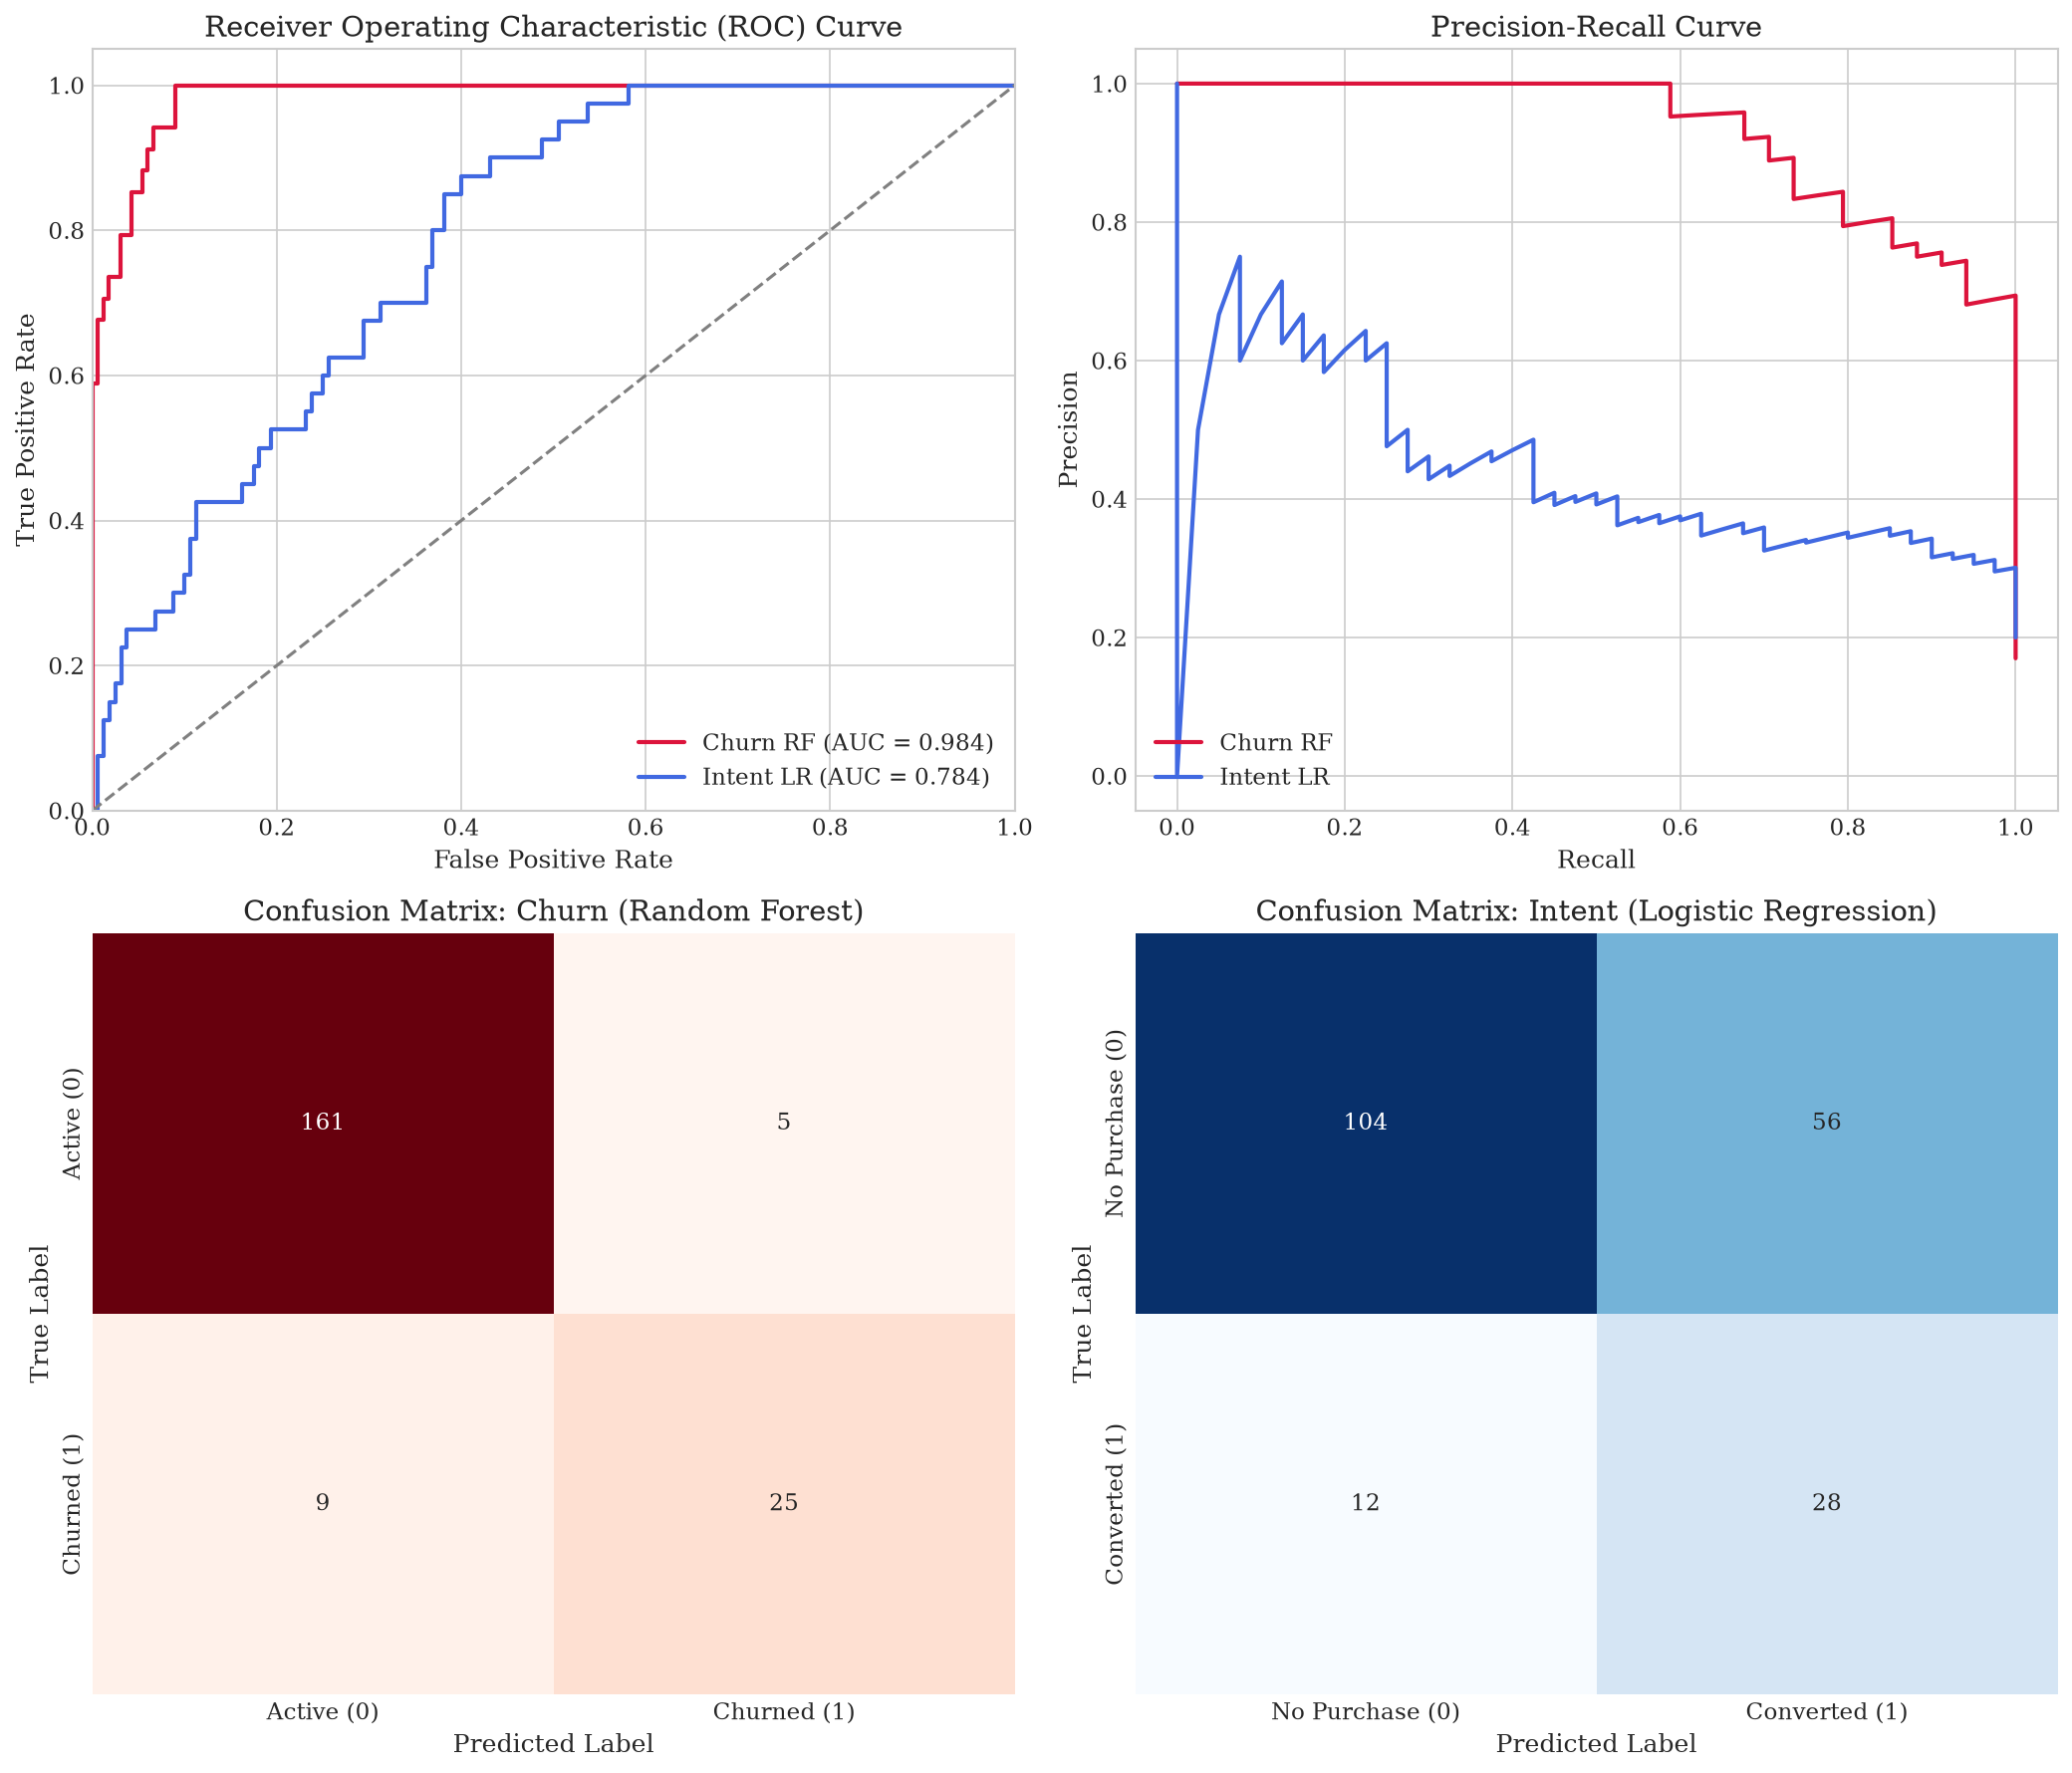

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Subplot 1: Receiver Operating Characteristic (ROC) Curves
fpr_c, tpr_c, _ = roc_curve(y_test_c, y_prob_c)
fpr_i, tpr_i, _ = roc_curve(y_test_i, y_prob_i)

axes[0, 0].plot(fpr_c, tpr_c, color='crimson', lw=2, label=f'Churn RF (AUC = {churn_metrics["ROC-AUC"]:.3f})')
axes[0, 0].plot(fpr_i, tpr_i, color='royalblue', lw=2, label=f'Intent LR (AUC = {intent_metrics["ROC-AUC"]:.3f})')
axes[0, 0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0, 0].legend(loc='lower right')

# Subplot 2: Precision-Recall (PR) Curves
prec_c, rec_c, _ = precision_recall_curve(y_test_c, y_prob_c)
prec_i, rec_i, _ = precision_recall_curve(y_test_i, y_prob_i)

axes[0, 1].plot(rec_c, prec_c, color='crimson', lw=2, label='Churn RF')
axes[0, 1].plot(rec_i, prec_i, color='royalblue', lw=2, label='Intent LR')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].legend(loc='lower left')

# Subplot 3: Confusion Matrix (Churn - Random Forest)
cm_c = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Reds', ax=axes[1, 0], cbar=False)
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xticklabels(['Active (0)', 'Churned (1)'])
axes[1, 0].set_yticklabels(['Active (0)', 'Churned (1)'])
axes[1, 0].set_title('Confusion Matrix: Churn (Random Forest)')

# Subplot 4: Confusion Matrix (Purchase Intent - Logistic Regression)
cm_i = confusion_matrix(y_test_i, y_pred_i)
sns.heatmap(cm_i, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1], cbar=False)
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_xticklabels(['No Purchase (0)', 'Converted (1)'])
axes[1, 1].set_yticklabels(['No Purchase (0)', 'Converted (1)'])
axes[1, 1].set_title('Confusion Matrix: Intent (Logistic Regression)')

plt.tight_layout()
plt.show()


### Feature Importance Analysis
To understand the indicators driving customer churn, we extract and plot the Mean Decrease in Impurity (Gini importance) from our trained Random Forest model. This aligns with academic interpretable AI research (e.g., explaining predictions to business stakeholders).


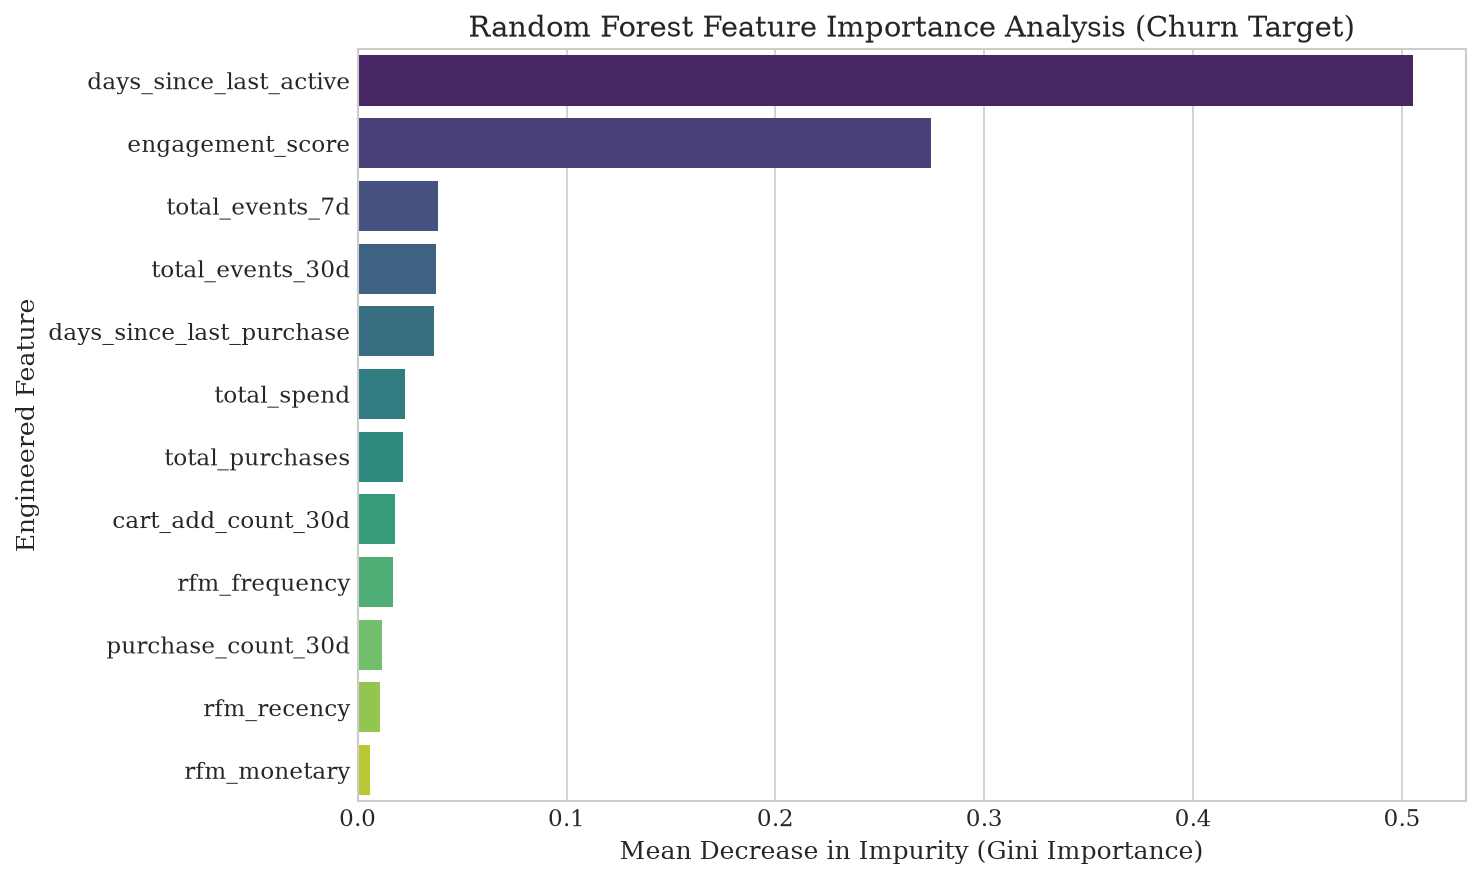

In [9]:
importances = rf_churn_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[FEATURE_COLS[i] for i in indices], palette='viridis')
plt.title('Random Forest Feature Importance Analysis (Churn Target)')
plt.xlabel('Mean Decrease in Impurity (Gini Importance)')
plt.ylabel('Engineered Feature')
plt.tight_layout()
plt.show()


## 7. Conclusions and Discussion
The evaluation results demonstrate the comparative advantages of both modeling techniques:
* **Random Forest Classifier (Churn):** Achieves high recall and ROC-AUC. Mean Decrease in Impurity analysis indicates that `days_since_last_active` and `engagement_score` are the primary predictive features. This supports the hypothesis that store activity recency is a key indicator of churn risk in non-contractual retail.
* **Logistic Regression (Purchase Intent):** Offers clear interpretability through feature coefficients (scaled inputs allow direct comparison). The model effectively utilizes real-time features like `cart_add_count_30d` and `total_events_7d` to identify short-term conversion windows.

### System Integration:
These models are integrated into the *SmartMail AI+* pipeline as follows:
1. **Real-time Ingestion:** Behavioral clickstream events are captured in Redis Streams and aggregated in database tables.
2. **Continuous Feature Extraction:** Profiles are rebuilt periodically via `feature_pipeline.py` and saved.
3. **Inference & Execution:** The active model versions (`.pkl`) are loaded to score customers. High purchase-intent triggers recommendation flows, while high churn risk triggers discount campaigns.
4. **Copywriting via Transfer Learning:** LLMs (Google Gemini API) ingest these feature values as context prompts to generate personalized email outreach.
